In [1]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("WineQuality.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0


In [3]:
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)
df.info()

Dataset Shape: (1699, 12)

Columns:
 Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1699 entries, 0 to 1698
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1699 non-null   float64
 1   volatile acidity      1699 non-null   float64
 2   citric acid           1699 non-null   float64
 3   residual sugar        1699 non-null   float64
 4   chlorides             1699 non-null   float64
 5   free sulfur dioxide   1699 non-null   float64
 6   total sulfur dioxide  1699 non-null   float64
 7   density               1699 non-null   float64
 8   pH                    1699 non-null   float64
 9   sulphates             1699 non-null   float64
 10  alcohol               1699 

In [4]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [5]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000
mean,8.329397,0.526786,0.271403,2.549096,0.087544,16.048253,46.897874,0.996747,3.311263,0.657206,10.421607,5.638028
std,1.726301,0.178695,0.194009,1.399910,0.046900,10.490591,32.733365,0.001887,0.154309,0.169189,1.066080,0.809308
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.094784,1.900000,0.070000,8.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.091000,22.000000,63.000000,0.997860,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


quality
5.000000    681
6.000000    638
7.000000    199
4.000000     53
8.000000     18
           ... 
3.897010      1
4.307249      1
5.409358      1
5.454616      1
6.737661      1
Name: count, Length: 106, dtype: int64


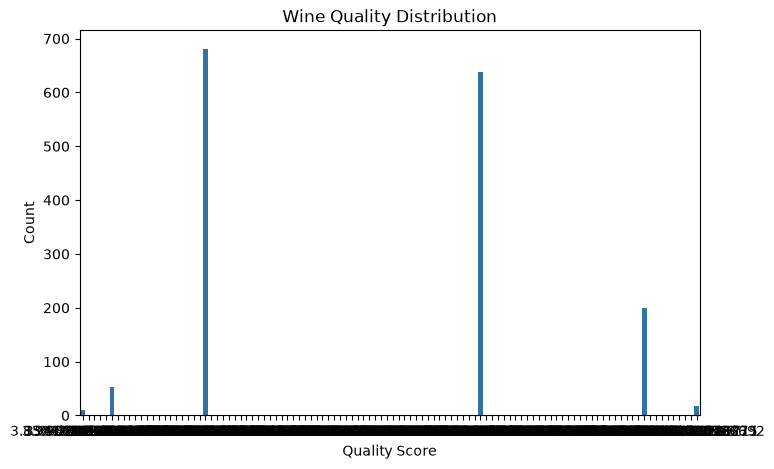

In [6]:
print(df['quality'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=df)

plt.title("Wine Quality Distribution")
plt.xlabel("Quality Score")
plt.ylabel("Count")

plt.show()

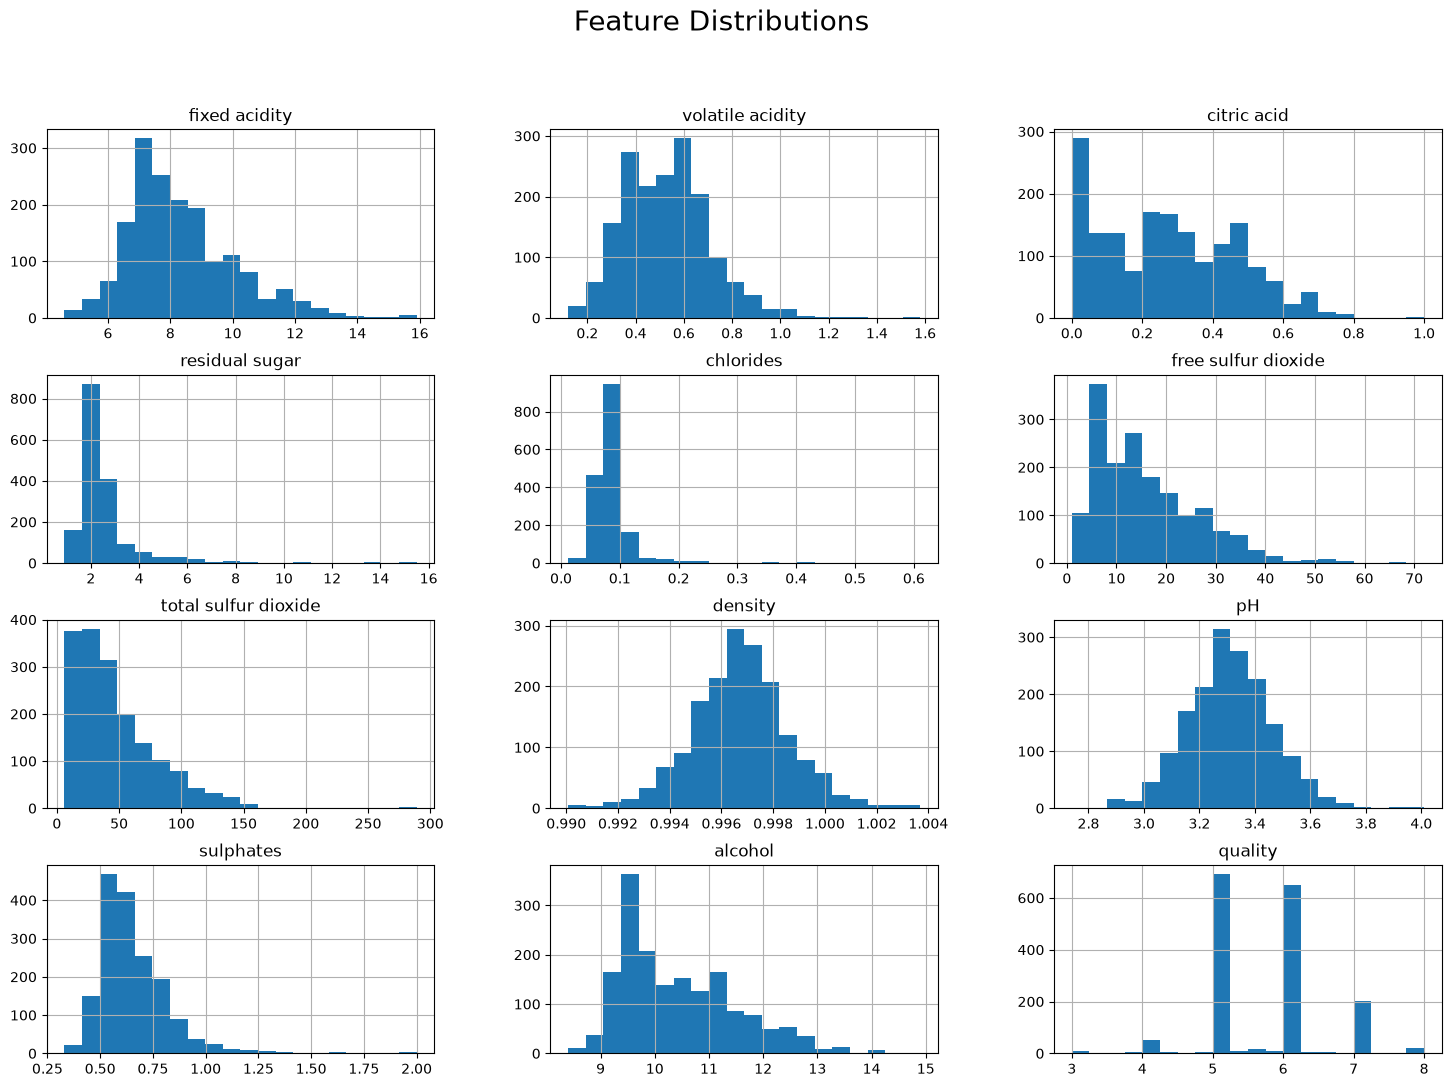

In [7]:
df.hist(figsize=(18,12), bins=20)

plt.suptitle("Feature Distributions", fontsize=20)

plt.show()

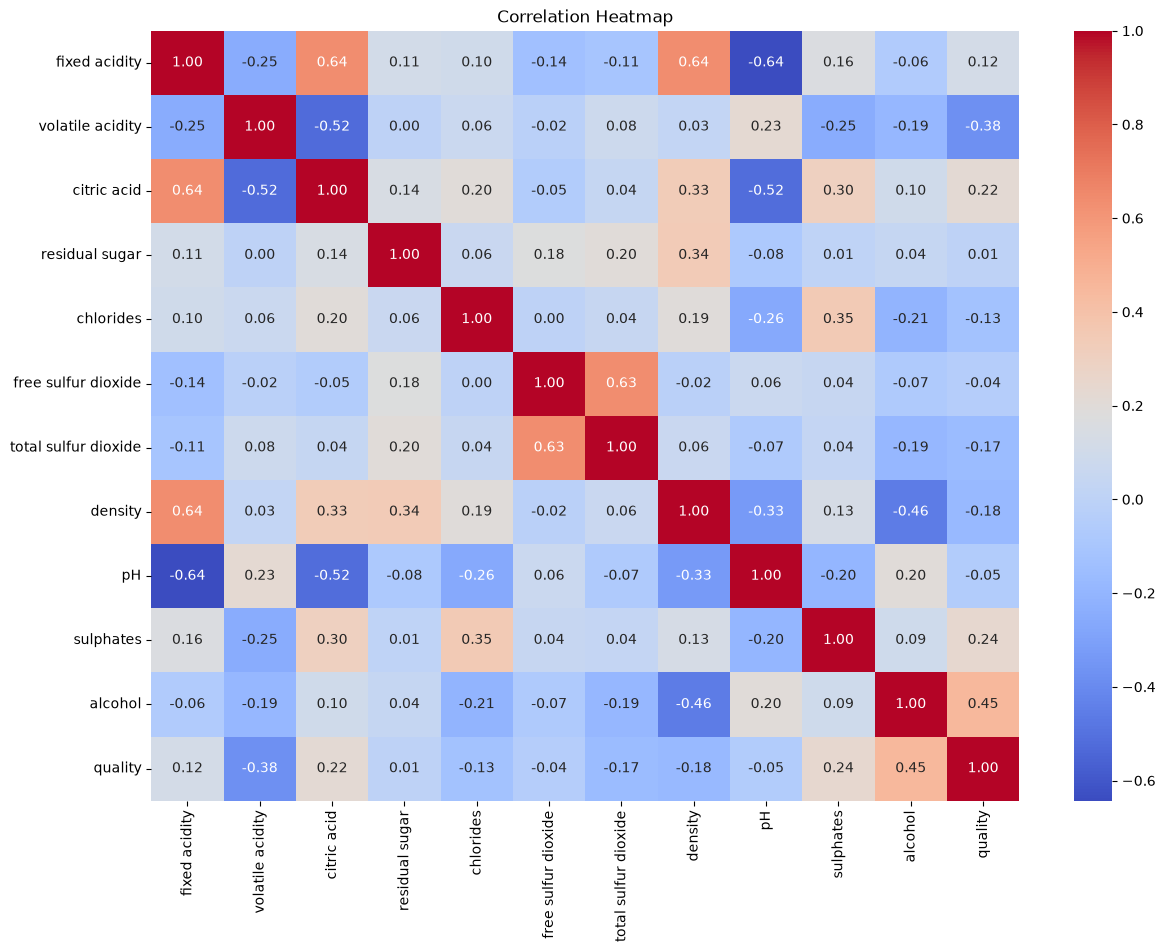

In [8]:

corr = df.corr()
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

In [9]:
quality_percent = df['quality'].value_counts(normalize=True) * 100

print(quality_percent)

quality
5.000000    40.082401
6.000000    37.551501
7.000000    11.712772
4.000000     3.119482
8.000000     1.059447
              ...    
3.897010     0.058858
4.307249     0.058858
5.409358     0.058858
5.454616     0.058858
6.737661     0.058858
Name: proportion, Length: 106, dtype: float64


In [10]:
df['quality'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

df['quality'].value_counts()

quality
0    1474
1     225
Name: count, dtype: int64

In [11]:
X = df.drop('quality', axis=1)

y = df['quality']

In [12]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1359, 11)
Testing Shape: (340, 11)


In [13]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9088235294117647


              precision    recall  f1-score   support

           0       0.92      0.98      0.95       295
           1       0.77      0.44      0.56        45

    accuracy                           0.91       340
   macro avg       0.84      0.71      0.76       340
weighted avg       0.90      0.91      0.90       340



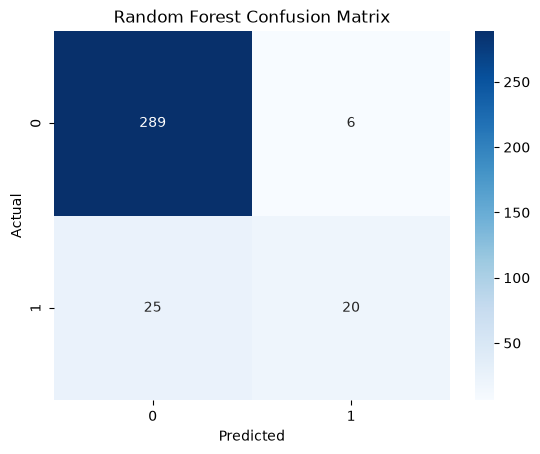

In [15]:
print(classification_report(y_test, rf_pred))


cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [16]:
sgd_model = SGDClassifier(random_state=42)

sgd_model.fit(X_train_scaled, y_train)


sgd_pred = sgd_model.predict(X_test_scaled)


sgd_accuracy = accuracy_score(y_test, sgd_pred)

print("SGD Accuracy:", sgd_accuracy)

SGD Accuracy: 0.85


              precision    recall  f1-score   support

           0       0.91      0.91      0.91       295
           1       0.43      0.44      0.44        45

    accuracy                           0.85       340
   macro avg       0.67      0.68      0.68       340
weighted avg       0.85      0.85      0.85       340



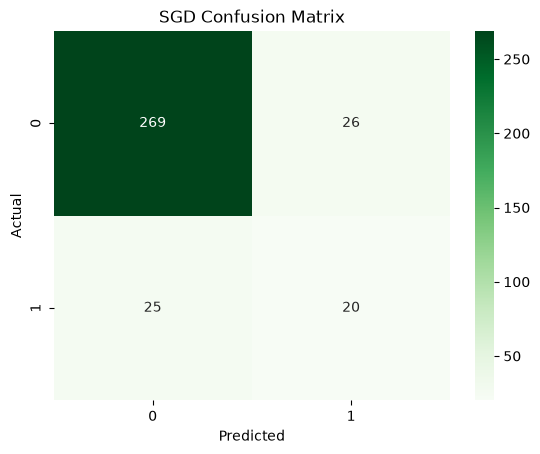

In [17]:
print(classification_report(y_test, sgd_pred))

cm = confusion_matrix(y_test, sgd_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("SGD Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [18]:
svc_model = SVC()

svc_model.fit(X_train_scaled, y_train)


svc_pred = svc_model.predict(X_test_scaled)


svc_accuracy = accuracy_score(y_test, svc_pred)

print("SVC Accuracy:", svc_accuracy)

SVC Accuracy: 0.888235294117647
